# SchurMO Analysis on Trained RNNs

Here we apply the SchurMO algorithm on the learned weights of the RNNS in rotated space to reveal hidden feedforward connectivity.

### Setup + Loading model weights

In [19]:
from pathlib import Path
import sys
REPO_ROOT = Path.cwd().parent
sys.path.append(str(REPO_ROOT))
from SchurMO.schurmo.motifs.chain.loss import make_chain_loss_factory
from SchurMO.schurmo.optimize.orthogonal_solver import OrthogonalSolver
from pymanopt import Problem
from pymanopt.manifolds import SpecialOrthogonalGroup
from pymanopt.optimizers import ConjugateGradient
from src.models.rnn import SequentialRNN
import torch
import seaborn as sns
import matplotlib.pyplot as plt

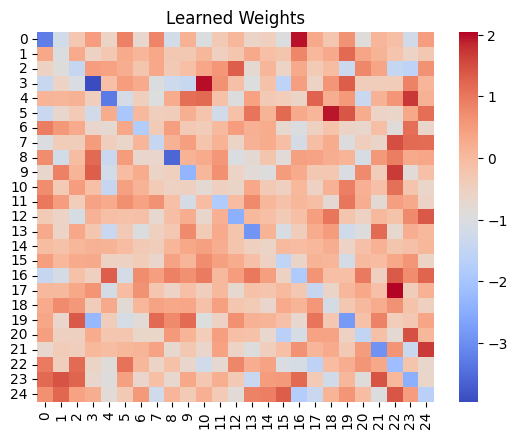

In [ ]:
hidden_size = 25
model = SequentialRNN(1, hidden_size, 'linear', rotation=True)
state_dict = torch.load("../data/model_weights/model.pth")
del state_dict['W_in']
model.load_state_dict(state_dict)
M_in = model.W_hh.weight.detach().numpy()
sns.heatmap(M_in, cmap="coolwarm").set_title("Learned Weights");

## Schur Manifold Optimization 

/Users/lakobian/miniforge3/lib/python3.12/site-packages/pymanopt/optimizers/conjugate_gradient.py:67: RuntimeWarning: invalid value encountered in divide
  manifold.inner_product(newx, Pnewgrad, diff)
/Users/lakobian/miniforge3/lib/python3.12/site-packages/pymanopt/optimizers/conjugate_gradient.py:67: RuntimeWarning: invalid value encountered in divide
  manifold.inner_product(newx, Pnewgrad, diff)
/Users/lakobian/miniforge3/lib/python3.12/site-packages/pymanopt/optimizers/conjugate_gradient.py:67: RuntimeWarning: invalid value encountered in divide
  manifold.inner_product(newx, Pnewgrad, diff)


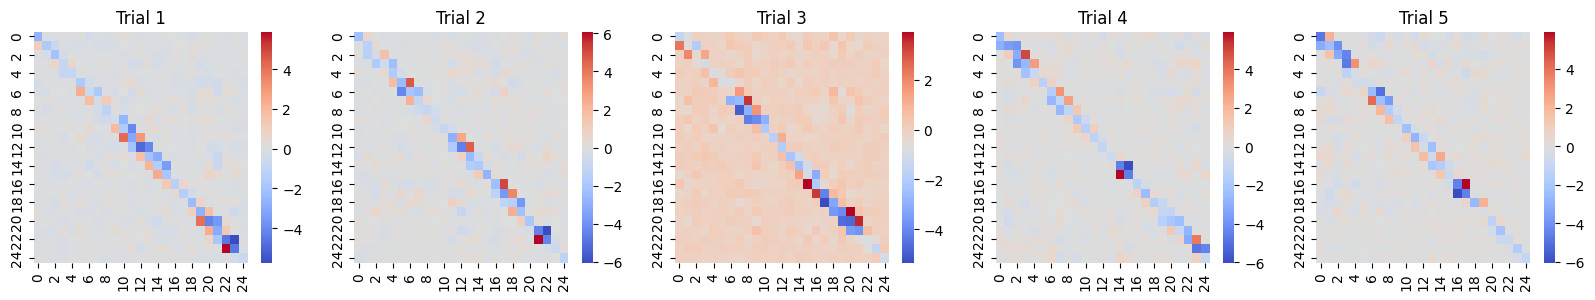

In [27]:
n_restarts = 5
fig, ax = plt.subplots(1, 5, figsize=(20, 3))

for n in range(n_restarts):
        
    solver = OrthogonalSolver(
        M_in,
        make_chain_loss_factory()
    )

    O_star, T_star, opt_cost, states, info = solver.run();
    sns.heatmap(T_star, cmap="coolwarm", ax=ax[n]).set_title(f"Trial {n+1}");
